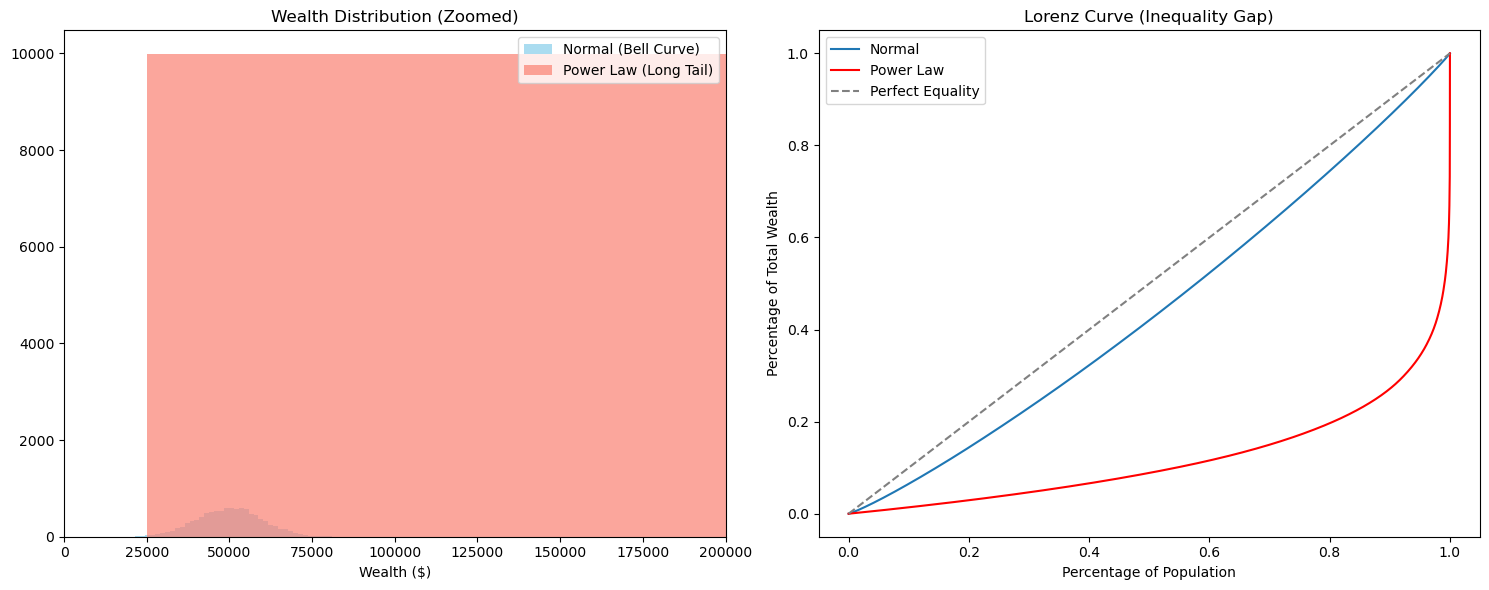

Top 1% Wealth Share (Normal): 1.5%
Top 1% Wealth Share (Power Law): 50.8%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup
n_people = 10000
bins = 50

# Normal Society (Everyone is roughly equal)
# Mean wealth $50k, standard deviation $10k
normal_wealth = np.random.normal(50000, 10000, n_people)

# Power Law Society (Pareto Distribution)
# alpha (shape) = 1.1 creates an extreme 'long tail'
alpha = 1.1 
power_law_wealth = (np.random.pareto(alpha, n_people) + 1) * 25000

# 2. Visualize the "Great Divide"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram: The Visual Difference
ax1.hist(normal_wealth, bins=bins, color='skyblue', alpha=0.7, label='Normal (Bell Curve)')
ax1.hist(power_law_wealth, bins=bins, color='salmon', alpha=0.7, label='Power Law (Long Tail)')
ax1.set_xlim(0, 200000) # Zooming in to see the bulk of the people
ax1.set_title("Wealth Distribution (Zoomed)")
ax1.set_xlabel("Wealth ($)")
ax1.legend()

# Lorenz Curve: Measuring Inequality
def lorenz_curve(data):
    scaled_prefix_sum = np.cumsum(np.sort(data)) / np.sum(data)
    return np.insert(scaled_prefix_sum, 0, 0)

ax2.plot(np.linspace(0.0, 1.0, n_people + 1), lorenz_curve(normal_wealth), label='Normal')
ax2.plot(np.linspace(0.0, 1.0, n_people + 1), lorenz_curve(power_law_wealth), label='Power Law', color='red')
ax2.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Equality')
ax2.set_title("Lorenz Curve (Inequality Gap)")
ax2.set_xlabel("Percentage of Population")
ax2.set_ylabel("Percentage of Total Wealth")
ax2.legend()

plt.tight_layout()
plt.show()

# 3. The "Quant" Stats
print(f"Top 1% Wealth Share (Normal): {np.sort(normal_wealth)[-100:].sum() / normal_wealth.sum():.1%}")
print(f"Top 1% Wealth Share (Power Law): {np.sort(power_law_wealth)[-100:].sum() / power_law_wealth.sum():.1%}")